## 0. Цель проекта

Решить <u>задачу бинарной классификации мошеннических транзакций</u> на несбалансированном датасете. Основной упор делается на  следующие методы и инструменты:

1) **сравнение бустинговых моделей**: обучение и сопоставление двух реализаций градиентного бустинга (baseline - Random Forest, продвинутые - XGBoost и CatBoost), их различия;

2) **метрики классификации**: $precision$, $recall$, $F$-$мера$, $ROC$-$AUC$ (+ построение ROC-кривых) и его ограниченная информативность в задаче фрода, PR-метрика (average precision score) и PR-кривая;

3) **теоретическая база**:
    - механика градиентного бустинга — градиентный спуск в пространстве функций: как деревья обучаются на антиградиенте функции потерь;

    - борьба с дисбалансом классов — использование весов классов, техники семплирования.

In [13]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve

# Тестируемые модели
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Техники сэмплирования
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## 1. Описание переменных в датасете и его импортирование

Датасет содержит транзакции по банковским картам. Задача — классифицировать транзакцию как **мошенническую (фродовую)** или **нормальную**.

- **`Time`** — время в секундах, прошедшее с первой транзакции в датасете.
- **`V1`–`V28`** — 28 анонимизированных числовых признаков, полученных через **PCA**.
- **`Amount`** — сумма транзакции.
- **`Class`** — целевая переменная: `0` — нормальная транзакция, `1` — мошенническая (фрод).

**Примечание:** классы сильно несбалансированы — фрод составляет лишь 0.17% от всех транзакций.

In [14]:
df = pd.read_csv('creditcard.csv')

print('Размерность датасета: ', df.shape)
df.head(10)

Размерность датасета:  (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


Пропусков в данных не обнаружено

In [15]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
print('Число дубликатов: ', df.duplicated().sum())

df[df.duplicated()]

Число дубликатов:  1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


Можем заметить, что некоторые операции дублируются, что избыточно и не нужно при обучении. Предлагаю удалить дубликаты, оставив лишь по 1 экземпляру в каждом подмножестве дубликатов.

In [17]:
df_cleaned = df.drop_duplicates(keep='first')
df_cleaned.shape

print(f'Удалена {df.shape[0] - df_cleaned.shape[0]} транзакция')

Удалена 1081 транзакция


Все признаки в датасете числовые - это удобно, так как не надо приводить их к одному виду

In [18]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

Еще дополнительно посмотрим на основные показатели датасета:
- виден сильный классовый перекос относительно **целевой переменной** `Class` в сторону 0 класса;
- в среднем люди переводят по 88 у.e. (определенная валюта).

In [19]:
df_cleaned.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


## 2. EDA

Взглянем на линейные зависимости среди признаков через корреляцию Пирсона

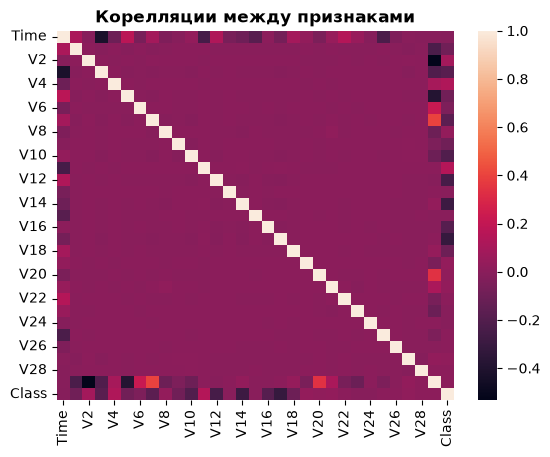

In [20]:
correlations = df_cleaned.corr()

sns.heatmap(correlations)
plt.title('Корелляции между признаками', fontweight='bold')

plt.show()

Несколько признаков имеет как положительную, так и отрицательную лмнейную связь с целевой перменной, при построении модели мы еще это увидим.

Теперь важно визуализировать `классовый дисбаланс`:

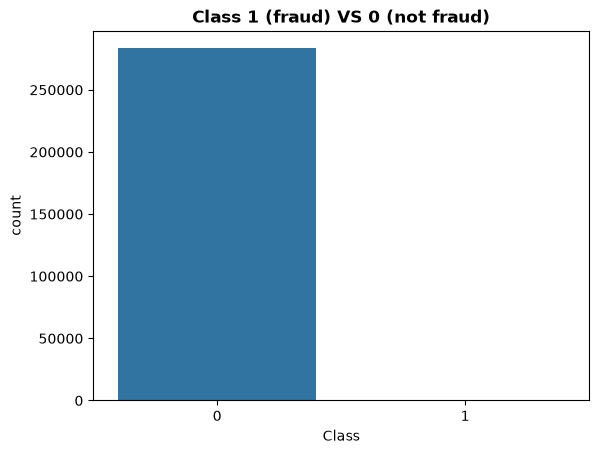

In [21]:
sns.countplot(data=df_cleaned, x='Class')

plt.title('Class 1 (fraud) VS 0 (not fraud)', fontweight='bold')

plt.show()

С таким огромным дисбалансом мы обязательно разберемся в разделе обучения модели - подберем скейлинговый параметр, чтобы модель учитывала это при обучении.

Посмотрим распределение признака `Amount` в разрезе `Time`:

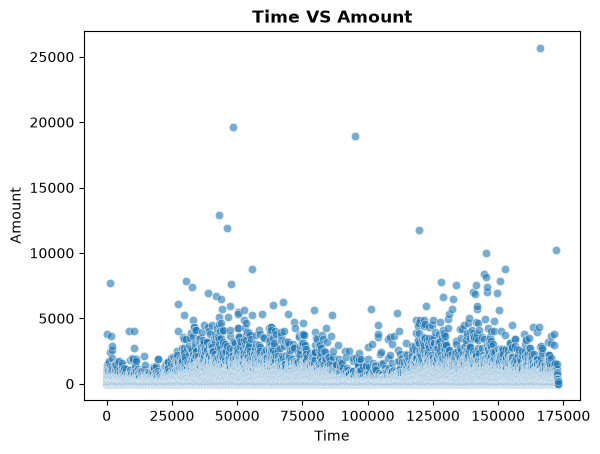

In [22]:
sns.scatterplot(data=df_cleaned, x=df_cleaned['Time'], y=df_cleaned['Amount'], alpha=0.6)
plt.title('Time VS Amount', fontweight='bold')

plt.show()

Посмотрим, как распределены транзакции и на какие суммы в основном они проводились

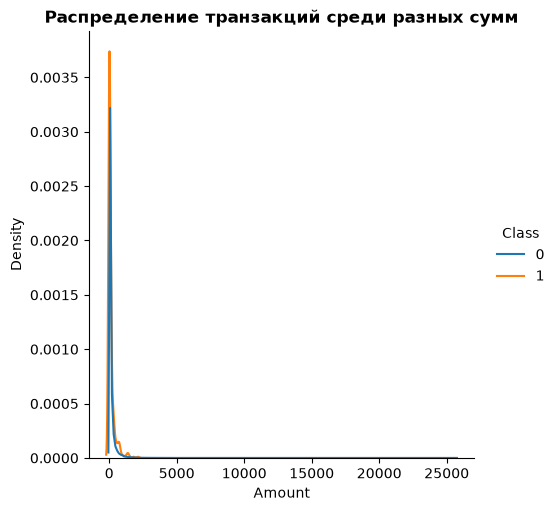

In [23]:
sns.displot(data=df_cleaned, x='Amount', hue='Class', kind='kde', common_norm=False)
plt.title('Распределение транзакций среди разных сумм', fontweight='bold')

plt.show()

**НАБЛЮДЕНИЕ:**
- В основном проводились транзакции на небольшие суммы (до 2500 у.e.)
- Виден большой скос влево и длинный правый хвост

Посмотрим на то, как скореллированные анонимные признаки ($V_{n}$) распределены по классам (определяли до этого):

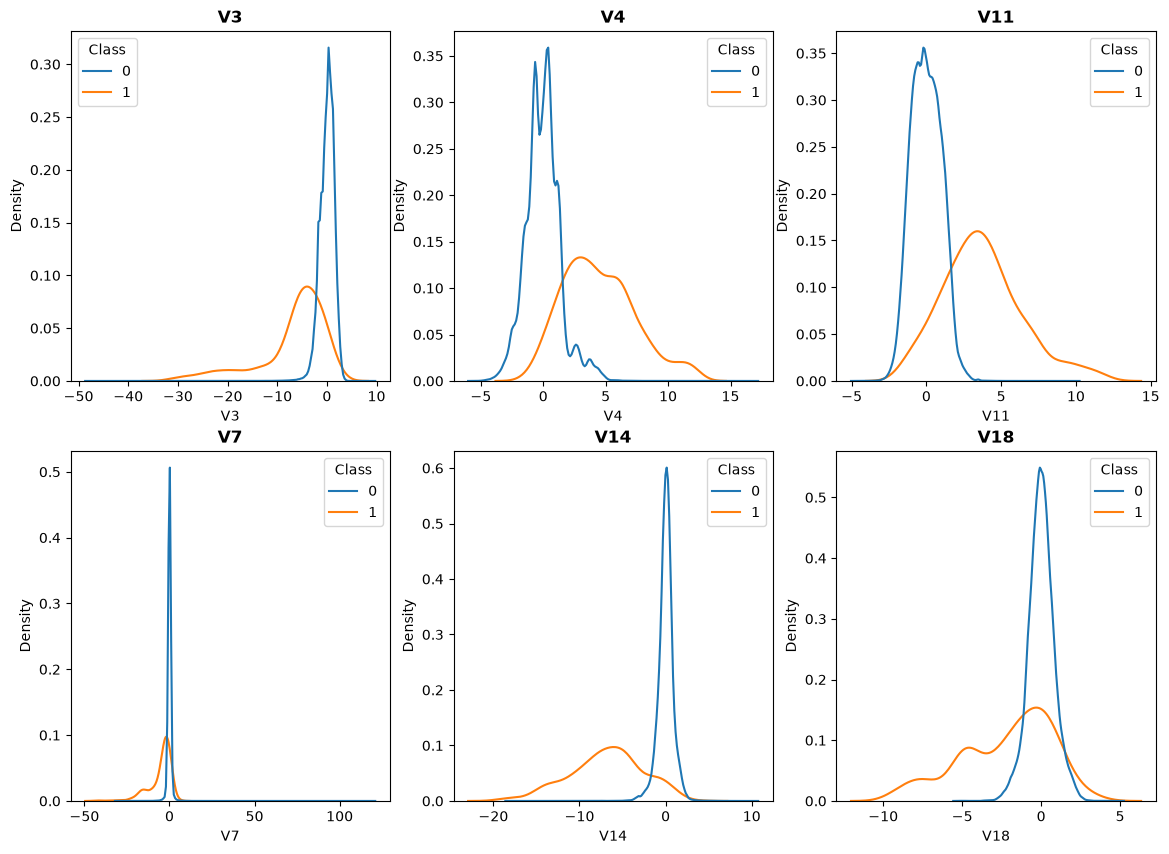

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten() # Делаем одномерный список из 6 осей
features = ['V3', 'V4', 'V11', 'V7', 'V14', 'V18']

for i, feature in enumerate(features):
    sns.kdeplot(data=df_cleaned, x=feature, hue='Class', common_norm=False, ax=axes[i])
    axes[i].set_title(feature, fontweight='bold')

plt.show()

**НАБЛЮДЕНИЯ:**
- У ынекоторых признаков распределения фрода и нормы заметно смещены друг относительно друга — модель сможет по ним отличать мошенничество. У фрода часто шире разброс и длинные хвосты в одну сторону, тогда как норма — узкий пик у нуля (что логично: PCA-компоненты центрированы, а фрод — аномалия, отклонение от «нормального» поведения).

## 3. Подбор и обучение моделей

Как уже описывалось ранее, здесь мы попробуем модели классификации, а именно модели градиентного бустинга для классификации.

В качестве бейзлайна используем  модель случайного леса, таким образом сравнив алгоритм градиентного спуска (а именно 2) с параллельным построением и обучением деревьев.

### ТЕОРИЯ ПО ГРАДИЕНТНОМУ БУСТИНГУ
- **Идея градиентного бустинга:** деревья строятся последовательно, и каждое следующее дерево обучается на **остатках (антиградиенте функции потерь)** предыдущих деревьев. <u>Важно</u>: градиентный спуск минимизирует не само предсказание, а **функцию потерь** $L$, то есть по текущему предсказанию $F(x)$, а не по весам. Новое дерево $h_m(x)$ приближает антиградиент лосса и прибавляется к текущему предсказанию с шагом $\eta$:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Таким образом, итоговое предсказание накапливает вклад всех деревьев и с каждым шагом уменьшает ошибку.

- **Как работает в контексте классификации?**

    Дерево выдаёт не метку, а скор $F(x)$ (лог-шансы), который через сигмоиду переводится в вероятность класса:

    $$p = \sigma(F(x)) = \frac{1}{1 + e^{-F(x)}}$$

    Функция потерь — log loss:

    $$L = -\big[y\ln p + (1-y)\ln(1-p)\big]$$

    Её антиградиент по предсказанию:

    $$-\frac{\partial L}{\partial F(x_i)} = y_i - p_i$$

    Логика аналогична бустингу в задаче регрессии: дерево обучается на остатке $y - p$, приближая вероятности к правильным. Финальная метка ставится по порогу:

    $$\hat{y} = \mathbb{1}[\,p \geq 0.5\,]$$

In [25]:
X = df_cleaned.drop(columns=['Class'])
y = df_cleaned['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3.1 Обучение с фиксом дисбаланса классов через их веса

In [26]:
scale = (y_train == 0).sum() / (y_train == 1).sum() # Для сложных моделей после baseline
scale

np.float64(584.8643067846608)

Базовая модель `Random Forest Classifier`:

In [27]:
baseline = RandomForestClassifier(class_weight='balanced', random_state=42)

baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

In [28]:
print('Precision (rf): ', round(precision_score(y_test, y_pred), 2))
print('Recall (rf): ', round(recall_score(y_test, y_pred), 2))
print('F1 (rf): ', round(f1_score(y_test, y_pred), 2))

Precision (rf):  0.91
Recall (rf):  0.77
F1 (rf):  0.83


Модель отработала отлично:
- Ловит 77% фрода
- 91% фрода помечается верно
- Среднее гармоническое между precision и recall высокое, что говорит о стабильности предсказаний модели

Модель `XGBoost`:

In [29]:
xb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale)
xb.fit(X_train, y_train)

y_pred_xb = xb.predict(X_test)

In [30]:
print('Precision (XGB): ', round(precision_score(y_test, y_pred_xb), 2))
print('Recall (XGB): ', round(recall_score(y_test, y_pred_xb), 2))
print('F1 (XGB): ', round(f1_score(y_test, y_pred_xb), 2))

Precision (XGB):  0.9
Recall (XGB):  0.78
F1 (XGB):  0.83


- Модель XGBoost немного лучше - теперь на 1 процент опредялем больше фрода и метим фрод более аккуратно.

Модель `CatBoost`:

In [31]:
cb = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)
cb.fit(X_train, y_train)

y_pred_cb = cb.predict(X_test)

In [32]:
print('Precision (CatBoost): ', round(precision_score(y_test, y_pred_cb), 2))
print('Recall (CatBoost): ', round(recall_score(y_test, y_pred_cb), 2))
print('F1 (CatBoost): ', round(f1_score(y_test, y_pred_cb), 2))

Precision (CatBoost):  0.81
Recall (CatBoost):  0.82
F1 (CatBoost):  0.82


- CatBoost оказалась наиболее эффективной в поимке фрода - она пропускает меньше мошенников, но больше ложных срабатываний (понизился Precision).

Посмотрим на ROC-AUC моделей:

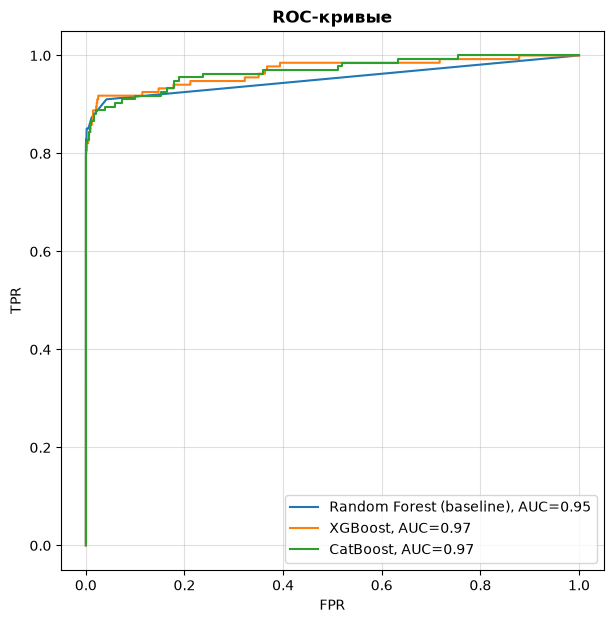

In [33]:
models = [('Random Forest (baseline)', baseline), ('XGBoost', xb), ('CatBoost', cb)]

plt.figure(figsize=(7, 7))

for name, m in models:
    proba = m.predict_proba(X_test)[:, 1] # Возвращает вероятность принадлежности к 1 классу
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.2f}')

plt.title('ROC-кривые', fontweight='bold')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.4)

plt.show()

**ВЫВОДЫ:**
- CatBoost и XGBoost эффективнее обычного бейзлайна, но неотличимы в рамках этой метрики друг от друга

- Модели неплохо отличают классы

## 3.2 Обучение с фиксом дисбаланса классов через семплирование

1) `SMOTE` — добавляет синтетические примеры фрода, пока классы не выровняются. Создаёт новые точки, интерполируя между существующими объектами меньшинства:

In [34]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Class
0    198269
1    198269
Name: count, dtype: int64


Обучим 3 модели в аналогичной последовательности на SMOTE-семплировании и сравним на них метрики:

`Random Forest Classifier`

In [35]:
baseline_smote = RandomForestClassifier(random_state=42)

baseline_smote.fit(X_train_smote, y_train_smote)
y_smote_pred = baseline_smote.predict(X_test)

print('Precision (rf SMOTE): ', round(precision_score(y_test, y_smote_pred), 2))
print('Recall (rf SMOTE): ', round(recall_score(y_test, y_smote_pred), 2))
print('F1 (rf SMOTE): ', round(f1_score(y_test, y_smote_pred), 2))

Precision (rf SMOTE):  0.9
Recall (rf SMOTE):  0.79
F1 (rf SMOTE):  0.84


`XGBoost`

In [36]:
xb_smote = XGBClassifier(random_state=42, eval_metric='logloss')
xb_smote.fit(X_train_smote, y_train_smote)

y_smote_pred_xb = xb_smote.predict(X_test)

print('Precision (XGB SMOTE): ', round(precision_score(y_test, y_smote_pred_xb), 2))
print('Recall (XGB SMOTE): ', round(recall_score(y_test, y_smote_pred_xb), 2))
print('F1 (XGB SMOTE): ', round(f1_score(y_test, y_smote_pred_xb ), 2))

Precision (XGB SMOTE):  0.83
Recall (XGB SMOTE):  0.8
F1 (XGB SMOTE):  0.81


`CatBoost`

In [37]:
cb_smote = CatBoostClassifier(random_state=42, verbose=0)
cb_smote.fit(X_train_smote, y_train_smote)

y_smote_pred_cb = cb_smote.predict(X_test)

print('Precision (CatBoost SMOTE): ', round(precision_score(y_test, y_smote_pred_cb), 2))
print('Recall (CatBoost SMOTE): ', round(recall_score(y_test, y_smote_pred_cb), 2))
print('F1 (CatBoost SMOTE): ', round(f1_score(y_test, y_smote_pred_cb), 2))

Precision (CatBoost SMOTE):  0.71
Recall (CatBoost SMOTE):  0.82
F1 (CatBoost SMOTE):  0.76


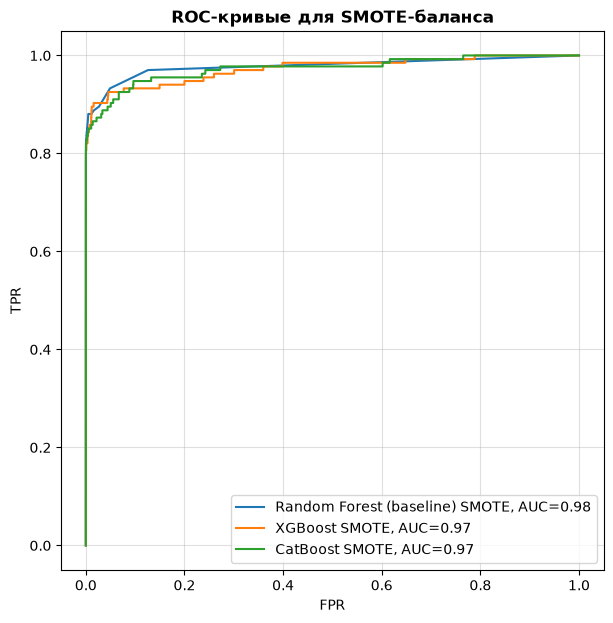

In [38]:
models = [('Random Forest (baseline) SMOTE', baseline_smote), ('XGBoost SMOTE', xb_smote), ('CatBoost SMOTE', cb_smote)]

plt.figure(figsize=(7, 7))

for name, m in models:
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.2f}')

plt.title('ROC-кривые для SMOTE-баланса', fontweight='bold')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.4)

plt.show()

---
2) `RandomUnderSampler` — это метод, который, наоборот, выкидывает случайную часть класса 0, пока классы не сравняются

In [39]:
random_sampler = RandomUnderSampler(random_state=42)
X_train_undersampling, y_train_undersampling = random_sampler.fit_resample(X_train, y_train)

print(y_train_undersampling.value_counts())

Class
0    339
1    339
Name: count, dtype: int64


`Random Forest Classifier`

In [40]:
baseline_undersampling = RandomForestClassifier(random_state=42)

baseline_undersampling.fit(X_train_undersampling, y_train_undersampling)
y_undersampling_pred = baseline_undersampling.predict(X_test)

print('Precision (rf UNDERSAMPLING): ', round(precision_score(y_test, y_undersampling_pred), 2))
print('Recall (rf UNDERSAMPLING): ', round(recall_score(y_test, y_undersampling_pred), 2))
print('F1 (rf UNDERSAMPLING): ', round(f1_score(y_test, y_undersampling_pred), 2))

Precision (rf UNDERSAMPLING):  0.05
Recall (rf UNDERSAMPLING):  0.88
F1 (rf UNDERSAMPLING):  0.1


`XGBoost`

In [41]:
xb_undersampling = XGBClassifier(random_state=42, eval_metric='logloss')
xb_undersampling.fit(X_train_undersampling, y_train_undersampling)

y_undersampling_pred_xb = xb_undersampling.predict(X_test)

print('Precision (XGB UNDERSAMPLING): ', round(precision_score(y_test, y_undersampling_pred_xb), 2))
print('Recall (XGB UNDERSAMPLING): ', round(recall_score(y_test, y_undersampling_pred_xb), 2))
print('F1 (XGB UNDERSAMPLING): ', round(f1_score(y_test, y_undersampling_pred_xb), 2))

Precision (XGB UNDERSAMPLING):  0.04
Recall (XGB UNDERSAMPLING):  0.9
F1 (XGB UNDERSAMPLING):  0.07


`CatBoost`

In [42]:
cb_undersampling = CatBoostClassifier(random_state=42, verbose=0)
cb_undersampling.fit(X_train_undersampling, y_train_undersampling)

y_undersampling_pred_cb = cb_undersampling.predict(X_test)

print('Precision (CatBoost UNDERSAMPLING): ', round(precision_score(y_test, y_undersampling_pred_cb ), 2))
print('Recall (CatBoost UNDERSAMPLING): ', round(recall_score(y_test, y_undersampling_pred_cb), 2))
print('F1 (CatBoost UNDERSAMPLING): ', round(f1_score(y_test, y_undersampling_pred_cb), 2))

Precision (CatBoost UNDERSAMPLING):  0.06
Recall (CatBoost UNDERSAMPLING):  0.88
F1 (CatBoost UNDERSAMPLING):  0.11


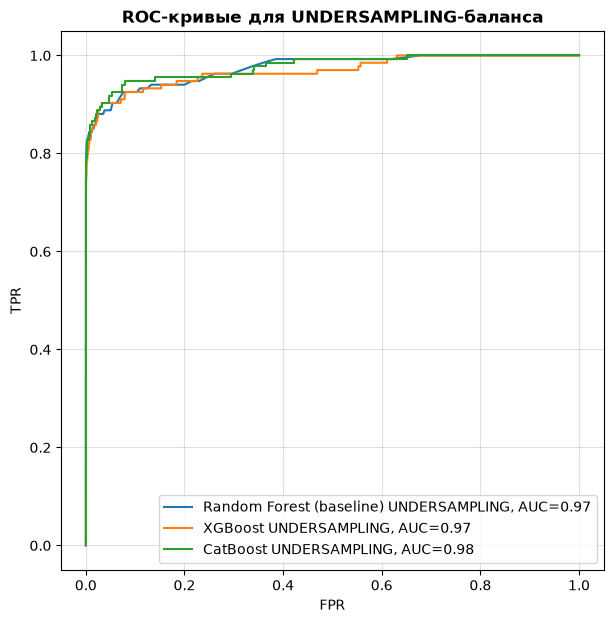

In [43]:
models = [('Random Forest (baseline) UNDERSAMPLING', baseline_undersampling), ('XGBoost UNDERSAMPLING', xb_undersampling), ('CatBoost UNDERSAMPLING', cb_undersampling)]

plt.figure(figsize=(7, 7))

for name, m in models:
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.2f}')

plt.title('ROC-кривые для UNDERSAMPLING-баланса', fontweight='bold')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.4)

plt.show()

---
`Оценим модели более информативной метрикой`
- ROC-AUC в контексте задачи фрода довольно бесполезен, так как мы хотим ловить редкий класс, учитывая и Precision, и Recall при различных порогах.
- Используем PR-метрику и кривую для оценки моделей

**Average Precision (PR):**

$$AP = \sum_{n} (R_n - R_{n-1}) P_n$$

где $P_n$ — Precision при n-м пороге,  
$R_n$ — Recall при n-м пороге,  
$(R_n - R_{n-1})$ — прирост recall.

In [64]:
def pr_countings(model, model_name, X_test, y_test, ax):
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    ax.plot(recall, precision, color='green')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{model_name}\nAverage Precision={pr_auc:.2f}', fontweight='bold')
    ax.grid(True)

    return pr_auc

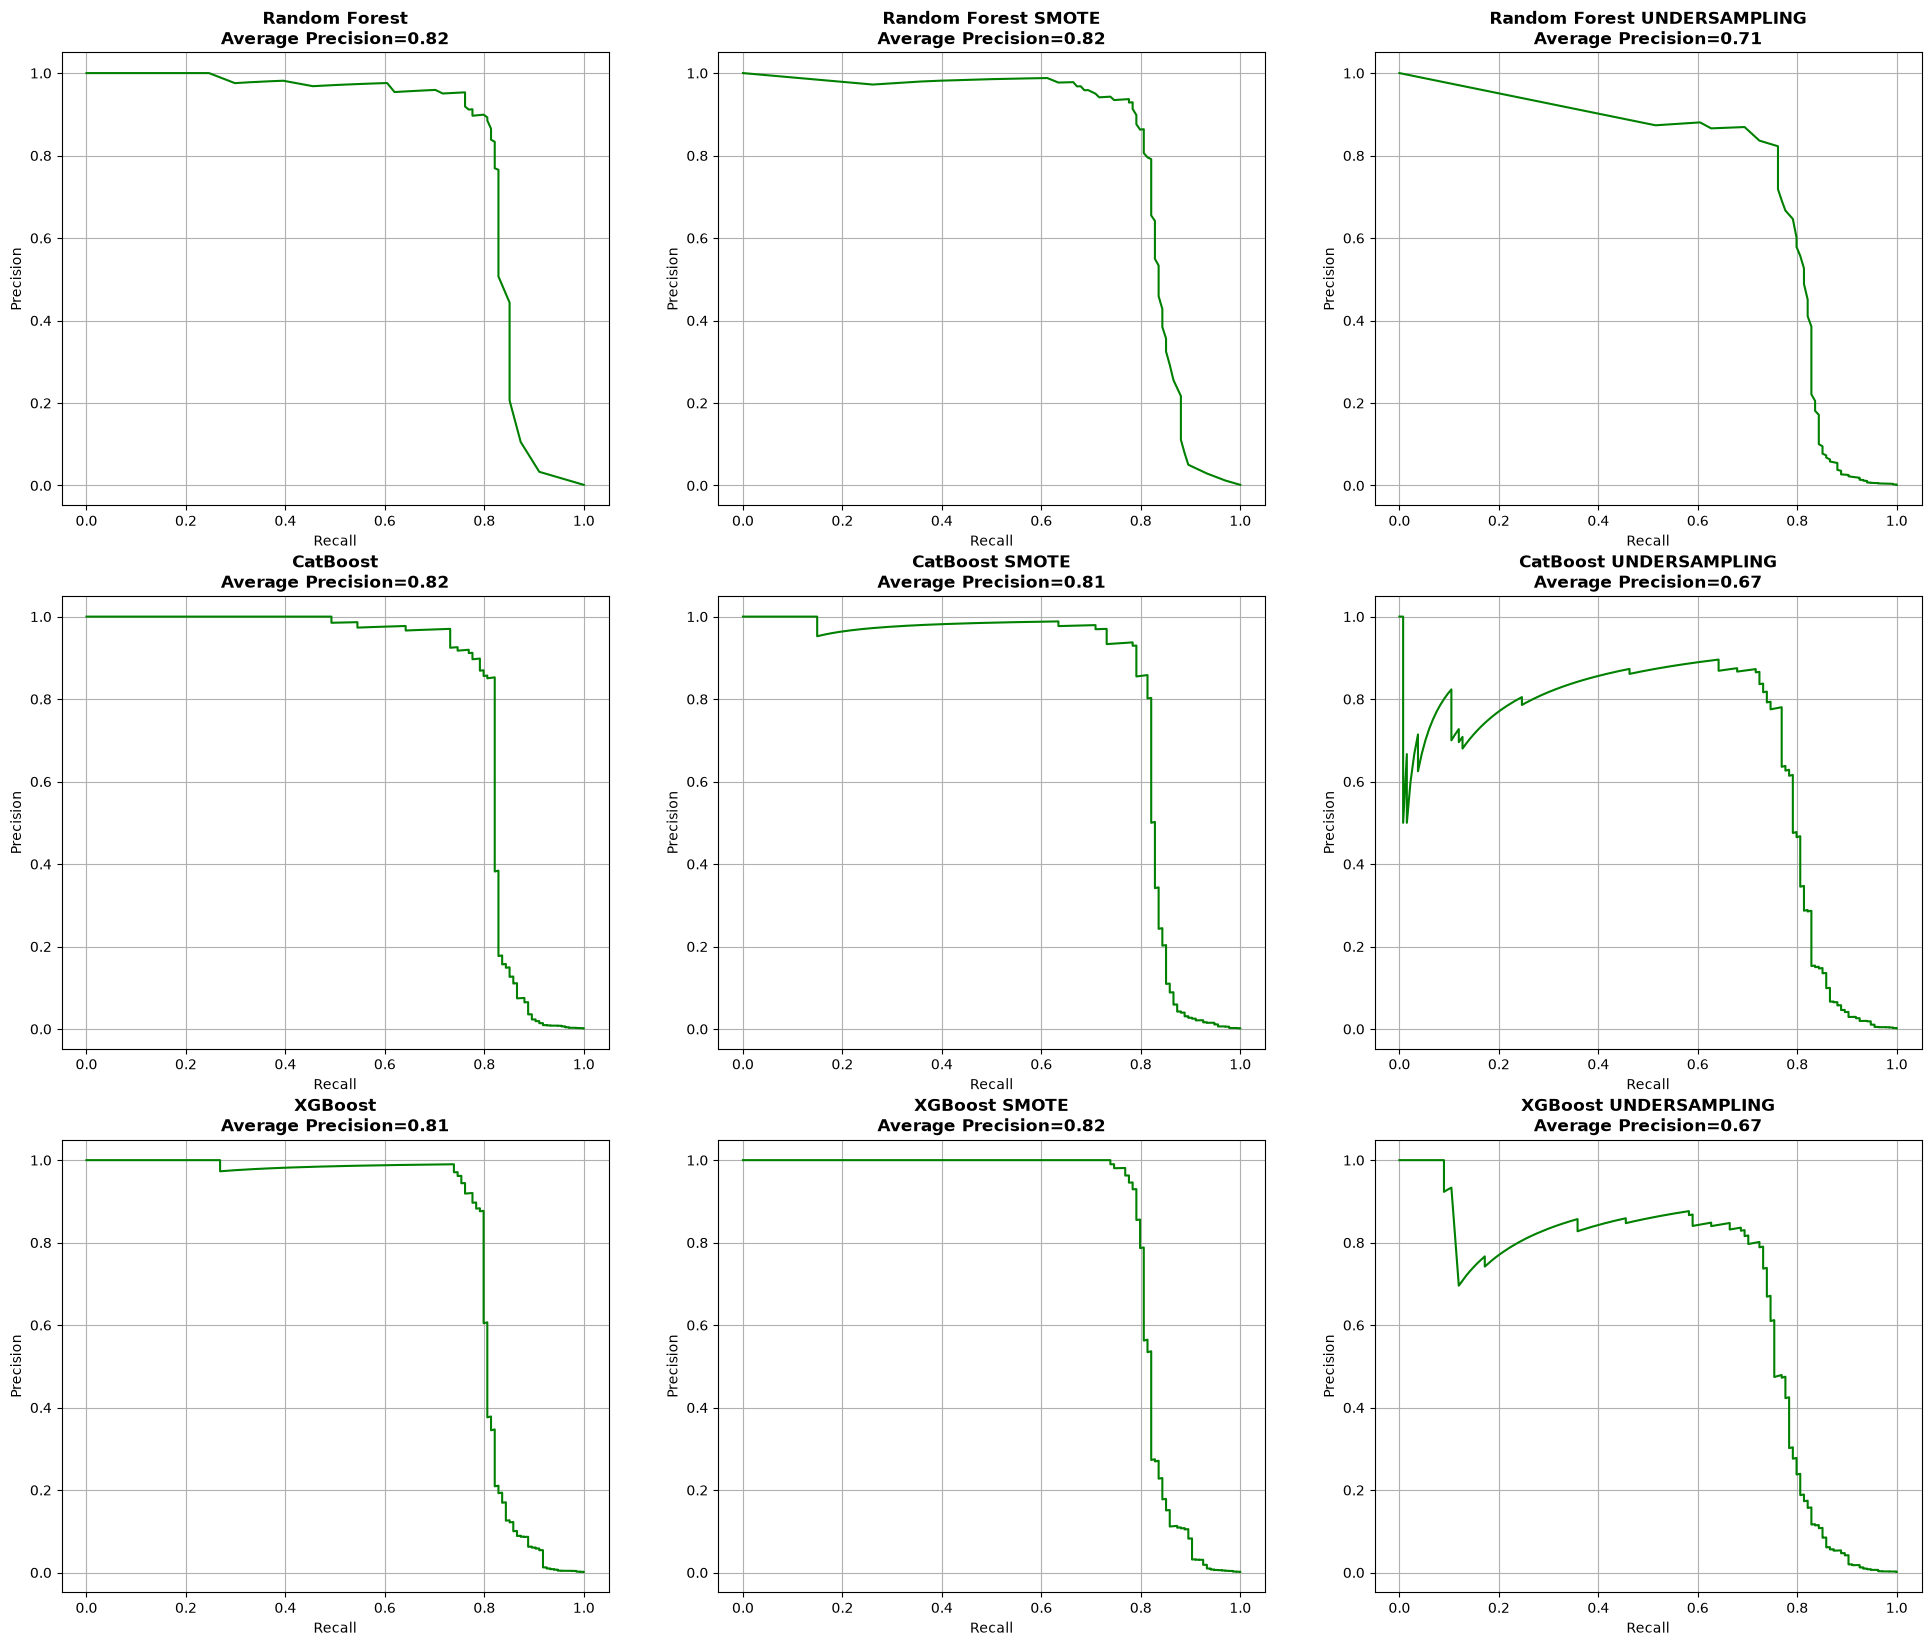

In [65]:
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

models = {'Random Forest': baseline, 'Random Forest SMOTE': baseline_smote, 'Random Forest UNDERSAMPLING': baseline_undersampling, 
        'CatBoost': cb, 'CatBoost SMOTE': cb_smote, 'CatBoost UNDERSAMPLING': cb_undersampling,
        'XGBoost': xb, 'XGBoost SMOTE': xb_smote, 'XGBoost UNDERSAMPLING': xb_undersampling}

axes = axes.ravel()
for i, (name, m) in enumerate(models.items()):
    curve = pr_countings(m, name, X_test, y_test, ax=axes[i])
    
plt.show()

## ИТОГ

**Семплирование:**
- `При Undersampling` очень сильно падает $Precision$ (до 4-6% на каждой модели), модель ловит почти весь фрод, но реальный фрод из них только 5%, то есть в основном это все ложные срабатывания. Это случилось из-за того, что мы выкинули почти все данные из исходного распределения, из-за чего модель стала подозревать почти все фродовым.

- `При SMOTE` показатели изменились даже в лучшую сторону - модель достроила фродовый класс, сохранив исходные данные о норме: особенно хорошо метод продемонстрировал себя в модели случайного леса, там выросли достаточно значимо все метрики.

$ROC$-$AUC$ у всех вариантов балансировки равен 0.95–0.98, то есть по нему модели и методы неотличимы. Даже провальный undersampling (precision 4–6%!) имеет $AUC$ 0.97–0.98, ровно как лучший Random Forest + SMOTE (precision 0.90). <u>Важное наблюдение</u>: на несбалансированных данных $ROC-AUC$ бесполезен для выбора модели, поскольку он всегда высокий.

Методы семплирования необходимы ТОЛЬКО для поднятия метрик классификации, фактически они не улучшают модель.

---

**Модели:**
- `XGBoost` и `CatBoost` оказались более эффективными по сравнению с бейзлайном - у них более сбалансированные метрики, высокий inference и быстрее время обучения.

- `CatBoost` без семплирования дает более высокий $Recall$, `XGBoost` и `Random Forest` дают более высокий $Precision$.

- Модель случайного леса в целом менее эффективна для этой задачи, тогда как градиентный бустинг смог уловить важные закономерности, строя деревья последовательно и исправляя ошибки предыдущих.

---

$PR-метрика$ и $PR-кривая$:

- По метрике PR `обычные модели` и `со SMOTE` отрабатывают примерно одинаково эффективно, а `Undersampling` показывает наихудшие результаты: мы выкинули большую часть 0 класса и модель стала хуже их определять.

- До Recall около 0.8 все модели работают одинаково хорошо, а далее резкий спад (мы начинаем сильно снижать порог классификации и метим фродом слишком много) -> в фрод попадает много обычных операций -> $Precision$ падает.